In [25]:
def convert_label(path):
    # Convert the path to a more readable label
    if path.startswith("lar"):
        return "Adapter Differential Larger KV Cache"
    elif path.startswith("sma"):
        return "Adapter Differential"
    elif path.startswith("diff"):
        return "Differential"
    elif path.startswith("vanilla"):
        return "Vanilla"
    else:
        return path.replace("_", " ").replace(".json", "")


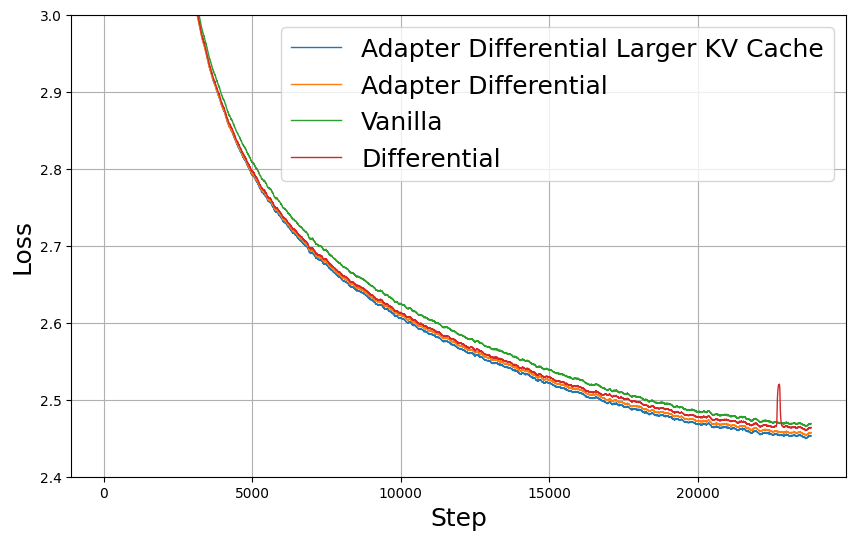

In [28]:
import glob
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# Find all files ending in trainer_state.json recursively
file_paths = glob.glob("**/*trainer_state.json", recursive=True)

plt.figure(figsize=(10, 6))

for path in file_paths:
    with open(path, "r") as f:
        data = json.load(f)

    # Extract steps and loss from log_history entries with a loss key
    steps = []
    losses = []
    for entry in data.get("log_history", []):
        if "loss" in entry and "step" in entry:
            steps.append(entry["step"])
            losses.append(entry["loss"])


    # Smooth the loss curve using a moving average
    def moving_average(x, w):
        return np.convolve(x, np.ones(w), 'valid') / w
    window_size = 100  # Adjust for more/less smoothing
    if steps and losses and len(losses) >= window_size:
        smooth_steps = steps[window_size-1:]
        smooth_losses = moving_average(losses, window_size)
        plt.plot(smooth_steps, smooth_losses, label=convert_label(os.path.basename(path)), linewidth=1)
    elif steps and losses:
        plt.plot(steps, losses, label=convert_label(os.path.basename(path)), linewidth=1)

plt.xlabel("Step", fontsize=18)
plt.ylabel("Loss", fontsize=18)
# plt.title("Loss Curves from trainer_state.json Files")

# Adjust y-axis to zoom in on differences (customize limits as needed)
plt.ylim(bottom=2.4, top=3)  # e.g., plt.ylim(0.1, 0.5)
# Or use logarithmic scale if appropriate:
# plt.yscale('log')
# Optionally, increase figure size for clarity:
# plt.gcf().set_size_inches(10, 6)

plt.legend(fontsize=18)
plt.grid(True)
plt.savefig("loss.pdf", bbox_inches="tight")
plt.show()
